# Research-Grade Multilingual Handwritten OCR Pipeline

This notebook is organized as a debug-first research pipeline for handwritten OCR.

Image Input -> Preprocessing -> Line Segmentation -> Word Segmentation -> Word-level Bounding Boxes -> Language Detection -> Language-specific OCR -> Post-processing

Design priorities:
- Every stage stores intermediate artifacts for inspection.
- Every transformation can be visualized independently.
- Language handling is modular and replaceable.
- Failure cases remain visible instead of being hidden inside a single black-box call.

Use this notebook in top-to-bottom order, or call `run_full_pipeline(...)` directly once the configuration is set.

## Configuration Section

All tunable parameters live here so the pipeline can be debugged and retuned without touching the stage logic.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import math
import re

import cv2
import editdistance
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont

try:
    import pytesseract
except Exception:
    pytesseract = None

try:
    from jiwer import wer as jiwer_wer
except Exception:
    jiwer_wer = None

DEBUG = True
SEED = 42
IMAGE_PATH: Optional[str] = None
OUTPUT_DPI = 120
FIGSIZE_SINGLE = (14, 8)
FIGSIZE_PAIR = (16, 8)

CONFIG: Dict[str, Any] = {
    "debug": DEBUG,
    "seed": SEED,
    "image_path": IMAGE_PATH,
    "output_dpi": OUTPUT_DPI,
    "preprocessing": {
        "clahe_clip_limit": 2.0,
        "clahe_tile_grid_size": (8, 8),
        "gaussian_blur_kernel": (3, 3),
        "denoise_strength": 5,
        "threshold_block_size": 31,
        "threshold_c": 11,
        "morph_kernel": (2, 2),
        "deskew_enabled": True,
    },
    "line_segmentation": {
        "projection_threshold_ratio": 0.06,
        "min_line_height": 10,
        "line_padding": 4,
    },
    "word_segmentation": {
        "min_contour_area": 40,
        "min_word_width": 8,
        "min_word_height": 10,
        "word_gap_factor": 1.35,
        "min_gap_threshold": 12,
        "max_gap_threshold": 80,
        "word_padding": 3,
    },
    "ocr": {
        "english": "eng",
        "marathi": "mar+hin",
        "tamil": "tam",
        "psm": 7,
        "oem": 1,
    },
    "language_map": {
        "Latin": ("English", 0.95),
        "Devanagari": ("Marathi", 0.95),
        "Tamil": ("Tamil", 0.95),
    },
}

np.random.seed(SEED)

@dataclass
class WordResult:
    line_index: int
    word_index: int
    bbox: Tuple[int, int, int, int]
    language: str
    language_confidence: float
    text: str
    ocr_confidence: float
    crop: Optional[np.ndarray] = field(default=None, repr=False)
    language_source: str = "unknown"

    def as_dict(self) -> Dict[str, Any]:
        return {
            "line_index": self.line_index,
            "word_index": self.word_index,
            "bbox": self.bbox,
            "language": self.language,
            "language_confidence": self.language_confidence,
            "text": self.text,
            "ocr_confidence": self.ocr_confidence,
            "language_source": self.language_source,
        }


@dataclass
class PipelineResult:
    original_image: np.ndarray
    debug: Dict[str, Any]
    lines: List[Dict[str, Any]]
    words: List[WordResult]
    reconstructed_text: str

    def to_dict(self) -> Dict[str, Any]:
        return {
            "original_image": self.original_image,
            "debug": self.debug,
            "lines": self.lines,
            "words": [word.as_dict() for word in self.words],
            "reconstructed_text": self.reconstructed_text,
        }


print("[OK] Imports and config loaded")
print(f"[OK] DEBUG = {DEBUG}")
print(f"[OK] pytesseract available = {pytesseract is not None}")

[OK] Imports and config loaded
[OK] DEBUG = True
[OK] pytesseract available = True


## Visualization Module

All plots are centralized here so every later stage can reuse the same debug presentation style.

In [2]:
def _to_display_image(image: np.ndarray) -> np.ndarray:
    """Convert a working image into a matplotlib-friendly representation."""
    if image is None:
        raise ValueError("image is None")
    if image.ndim == 2:
        return image
    if image.ndim == 3 and image.shape[2] == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if image.ndim == 3 and image.shape[2] == 1:
        return image[:, :, 0]
    return image


def show_image(title: str, image: np.ndarray, cmap: str = "gray", figsize: Tuple[int, int] = FIGSIZE_SINGLE, force: bool = False) -> None:
    """Show a single image with a stable debug layout."""
    if not (DEBUG or force):
        return
    display_image = _to_display_image(image)
    plt.figure(figsize=figsize, dpi=OUTPUT_DPI)
    if display_image.ndim == 2:
        plt.imshow(display_image, cmap=cmap)
    else:
        plt.imshow(display_image)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_side_by_side(img1: np.ndarray, img2: np.ndarray, title1: str, title2: str, figsize: Tuple[int, int] = FIGSIZE_PAIR, force: bool = False) -> None:
    """Compare before/after images without hiding details in a montage."""
    if not (DEBUG or force):
        return
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=OUTPUT_DPI)
    for ax, img, title in zip(axes, [img1, img2], [title1, title2]):
        display_image = _to_display_image(img)
        if display_image.ndim == 2:
            ax.imshow(display_image, cmap="gray")
        else:
            ax.imshow(display_image)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_bounding_boxes(image: np.ndarray, boxes: Sequence[Tuple[int, int, int, int]], labels: Optional[Sequence[str]] = None, color: Tuple[int, int, int] = (0, 255, 0), title: str = "Bounding Boxes", force: bool = False) -> None:
    """Overlay boxes and optional labels on top of an image for inspection."""
    if not (DEBUG or force):
        return
    annotated = _to_display_image(image).copy()
    if annotated.ndim == 2:
        annotated = cv2.cvtColor(annotated, cv2.COLOR_GRAY2RGB)
    else:
        annotated = annotated.copy()
    for index, box in enumerate(boxes):
        x, y, w, h = box
        cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 2)
        if labels and index < len(labels):
            label = str(labels[index])
            cv2.putText(annotated, label, (x, max(12, y - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    plt.figure(figsize=FIGSIZE_SINGLE, dpi=OUTPUT_DPI)
    plt.imshow(annotated)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_projection_profiles(image: np.ndarray, title: str = "Projection Profiles", force: bool = False) -> None:
    """Show row and column projections because segmentation failures often appear here first."""
    if not (DEBUG or force):
        return
    gray = image if image.ndim == 2 else cv2.cvtColor(_to_display_image(image), cv2.COLOR_RGB2GRAY)
    binary = (gray < 200).astype(np.uint8)
    row_profile = binary.sum(axis=1)
    col_profile = binary.sum(axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=OUTPUT_DPI)
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Source")
    axes[1].plot(row_profile, color="steelblue")
    axes[1].set_title("Row projection")
    axes[2].plot(col_profile, color="darkorange")
    axes[2].set_title("Column projection")
    for ax in axes:
        ax.axis("off") if ax is axes[0] else None
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_stage_grid(images: Sequence[np.ndarray], titles: Sequence[str], ncols: int = 2, force: bool = False) -> None:
    """Show a compact debug panel for sequential stage outputs."""
    if not (DEBUG or force):
        return
    n_images = len(images)
    nrows = int(math.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), dpi=OUTPUT_DPI)
    axes = np.array(axes).reshape(-1)
    for axis, image, title in zip(axes, images, titles):
        display_image = _to_display_image(image)
        if display_image.ndim == 2:
            axis.imshow(display_image, cmap="gray")
        else:
            axis.imshow(display_image)
        axis.set_title(title)
        axis.axis("off")
    for axis in axes[n_images:]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()


print("[OK] Visualization module ready")

[OK] Visualization module ready


## Preprocessing Module

This stage converts raw scans into a controlled binary representation while keeping the original image available for comparison.

In [3]:
def load_image(image_input: Union[str, Path, np.ndarray]) -> np.ndarray:
    """Load an image from disk or pass through an in-memory numpy array."""
    if isinstance(image_input, np.ndarray):
        image = image_input.copy()
    else:
        image_path = Path(image_input)
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image is None:
            raise ValueError(f"Unable to read image: {image_path}")
    return image


def generate_demo_image(width: int = 1400, height: int = 500) -> np.ndarray:
    """Create a simple synthetic page so the pipeline can be debugged without external data."""
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    lines = [
        "Multilingual OCR debug demo",
        "English words are easy to inspect here",
        "Marathi and Tamil support can be tested on real scans",
    ]
    y = 90
    for line in lines:
        cv2.putText(canvas, line, (40, y), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (20, 20, 20), 2, cv2.LINE_AA)
        y += 120
    cv2.rectangle(canvas, (28, 24), (width - 28, height - 24), (220, 220, 220), 1)
    return canvas


def convert_to_grayscale(image: np.ndarray) -> np.ndarray:
    """Convert to grayscale because downstream OCR and projection logic work on intensity."""
    if image.ndim == 2:
        return image.copy()
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def enhance_contrast(gray: np.ndarray) -> np.ndarray:
    """Use CLAHE so faded handwriting becomes easier to threshold."""
    clahe_cfg = CONFIG["preprocessing"]
    clahe = cv2.createCLAHE(
        clipLimit=clahe_cfg["clahe_clip_limit"],
        tileGridSize=clahe_cfg["clahe_tile_grid_size"],
    )
    return clahe.apply(gray)


def remove_noise(gray: np.ndarray) -> np.ndarray:
    """Apply a small blur before thresholding to suppress sensor noise without erasing strokes."""
    kernel = CONFIG["preprocessing"]["gaussian_blur_kernel"]
    return cv2.GaussianBlur(gray, kernel, 0)


def threshold_image(gray: np.ndarray) -> np.ndarray:
    """Binary inversion keeps ink as foreground, which simplifies projection and contour logic."""
    block_size = CONFIG["preprocessing"]["threshold_block_size"]
    block_size = block_size if block_size % 2 == 1 else block_size + 1
    threshold_c = CONFIG["preprocessing"]["threshold_c"]
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        block_size,
        threshold_c,
    )
    return binary


def clean_binary(binary: np.ndarray) -> np.ndarray:
    """Close small breaks and remove isolated dots while leaving word shapes visible."""
    kernel_size = CONFIG["preprocessing"]["morph_kernel"]
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=1)
    return cleaned


def deskew_image(binary: np.ndarray) -> np.ndarray:
    """Deskew if the dominant text direction is tilted, which stabilizes projection peaks."""
    if not CONFIG["preprocessing"]["deskew_enabled"]:
        return binary
    coords = np.column_stack(np.where(binary > 0))
    if coords.size == 0:
        return binary
    rect = cv2.minAreaRect(coords[:, ::-1].astype(np.float32))
    angle = rect[-1]
    if angle < -45:
        angle = 90 + angle
    elif angle > 45:
        angle = angle - 90
    if abs(angle) < 0.5:
        return binary
    (h, w) = binary.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(binary, matrix, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


def preprocess_image(image_input: Union[str, Path, np.ndarray], debug: bool = True) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """Run the full preprocessing stack and keep every intermediate artifact."""
    original = load_image(image_input)
    gray = convert_to_grayscale(original)
    denoised = remove_noise(gray)
    enhanced = enhance_contrast(denoised)
    thresholded = threshold_image(enhanced)
    cleaned = clean_binary(thresholded)
    deskewed = deskew_image(cleaned)

    debug_bundle = {
        "original": original,
        "gray": gray,
        "denoised": denoised,
        "enhanced": enhanced,
        "thresholded": thresholded,
        "cleaned": cleaned,
        "deskewed": deskewed,
    }

    if debug:
        show_side_by_side(original, gray, "Original", "Grayscale")
        show_stage_grid(
            [denoised, enhanced, thresholded, cleaned, deskewed],
            ["Denoised", "Contrast enhanced", "Thresholded", "Morph cleaned", "Deskewed"],
            ncols=2,
        )

    return deskewed, debug_bundle


print("[OK] Preprocessing module ready")

[OK] Preprocessing module ready


## Segmentation Module

Line segmentation is projection-driven; word segmentation is contour-driven with adaptive gap clustering.

In [4]:
def _contiguous_runs(mask: np.ndarray) -> List[Tuple[int, int]]:
    """Return [start, end) index ranges for True runs in a boolean mask."""
    runs: List[Tuple[int, int]] = []
    start_index: Optional[int] = None
    for index, value in enumerate(mask.tolist()):
        if value and start_index is None:
            start_index = index
        elif not value and start_index is not None:
            runs.append((start_index, index))
            start_index = None
    if start_index is not None:
        runs.append((start_index, len(mask)))
    return runs


def segment_lines(binary_image: np.ndarray, debug: bool = True) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Segment text lines using horizontal projection profiles."""
    line_cfg = CONFIG["line_segmentation"]
    row_profile = (binary_image > 0).sum(axis=1)
    threshold_value = max(int(binary_image.shape[1] * line_cfg["projection_threshold_ratio"]), line_cfg["min_line_height"])
    active_rows = row_profile >= threshold_value
    runs = _contiguous_runs(active_rows)

    line_boxes: List[Dict[str, Any]] = []
    for line_index, (start_row, end_row) in enumerate(runs):
        start_row = max(0, start_row - line_cfg["line_padding"])
        end_row = min(binary_image.shape[0], end_row + line_cfg["line_padding"])
        if end_row - start_row < line_cfg["min_line_height"]:
            continue
        line_boxes.append({
            "line_index": line_index,
            "bbox": (0, start_row, binary_image.shape[1], end_row - start_row),
            "binary_crop": binary_image[start_row:end_row, :],
        })

    debug_bundle = {
        "row_profile": row_profile,
        "threshold_value": threshold_value,
        "active_rows": active_rows,
        "line_boxes": line_boxes,
    }

    if debug:
        show_projection_profiles(binary_image, title="Line Segmentation: Projection Profiles")
        if line_boxes:
            boxes = [entry["bbox"] for entry in line_boxes]
            labels = [f"L{i}" for i in range(len(line_boxes))]
            show_bounding_boxes(binary_image, boxes, labels=labels, color=(255, 0, 0), title="Detected Text Lines")

    return line_boxes, debug_bundle


def _normalize_word_boxes(boxes: List[Tuple[int, int, int, int]]) -> List[Tuple[int, int, int, int]]:
    return sorted(boxes, key=lambda box: (box[1], box[0]))


def _cluster_boxes_by_gap(boxes: List[Tuple[int, int, int, int]]) -> List[List[Tuple[int, int, int, int]]]:
    """Cluster contour boxes into words using an adaptive horizontal gap threshold."""
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda item: item[0])
    gaps: List[int] = []
    for left_box, right_box in zip(boxes[:-1], boxes[1:]):
        gap = right_box[0] - (left_box[0] + left_box[2])
        if gap > 0:
            gaps.append(gap)
    if gaps:
        average_gap = float(np.mean(gaps))
    else:
        average_gap = float(CONFIG["word_segmentation"]["min_gap_threshold"])
    threshold = int(np.clip(
        average_gap * CONFIG["word_segmentation"]["word_gap_factor"],
        CONFIG["word_segmentation"]["min_gap_threshold"],
        CONFIG["word_segmentation"]["max_gap_threshold"],
    ))

    clusters: List[List[Tuple[int, int, int, int]]] = [[boxes[0]]]
    for current_box in boxes[1:]:
        previous_box = clusters[-1][-1]
        gap = current_box[0] - (previous_box[0] + previous_box[2])
        if gap <= threshold:
            clusters[-1].append(current_box)
        else:
            clusters.append([current_box])
    return clusters


def segment_words(line_binary: np.ndarray, line_bbox: Tuple[int, int, int, int], debug: bool = True, line_index: int = 0) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Segment words from a single line using contours and adaptive gap grouping."""
    x0, y0, line_width, line_height = line_bbox
    word_cfg = CONFIG["word_segmentation"]
    contours, _ = cv2.findContours(line_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_boxes: List[Tuple[int, int, int, int]] = []
    contour_stats: List[Dict[str, Any]] = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = int(w * h)
        if area < word_cfg["min_contour_area"]:
            continue
        if w < word_cfg["min_word_width"] or h < word_cfg["min_word_height"]:
            continue
        contour_boxes.append((x, y, w, h))
        contour_stats.append({"bbox": (x, y, w, h), "area": area})

    contour_boxes = _normalize_word_boxes(contour_boxes)
    clustered_boxes = _cluster_boxes_by_gap(contour_boxes)

    word_segments: List[Dict[str, Any]] = []
    for word_index, cluster in enumerate(clustered_boxes):
        xs = [box[0] for box in cluster]
        ys = [box[1] for box in cluster]
        x2s = [box[0] + box[2] for box in cluster]
        y2s = [box[1] + box[3] for box in cluster]
        padding = word_cfg["word_padding"]
        local_x = max(0, min(xs) - padding)
        local_y = max(0, min(ys) - padding)
        local_w = min(line_binary.shape[1], max(x2s) + padding) - local_x
        local_h = min(line_binary.shape[0], max(y2s) + padding) - local_y
        global_bbox = (x0 + local_x, y0 + local_y, local_w, local_h)
        word_segments.append({
            "line_index": line_index,
            "word_index": word_index,
            "bbox": global_bbox,
            "local_bbox": (local_x, local_y, local_w, local_h),
            "contours": cluster,
            "crop": line_binary[local_y:local_y + local_h, local_x:local_x + local_w],
        })

    debug_bundle = {
        "contour_boxes": contour_boxes,
        "contour_stats": contour_stats,
        "clustered_boxes": clustered_boxes,
        "word_segments": word_segments,
    }

    if debug:
        if contour_boxes:
            show_bounding_boxes(line_binary, contour_boxes, title=f"Line {line_index}: Contours")
        if word_segments:
            local_boxes = [segment["local_bbox"] for segment in word_segments]
            labels = [f"W{index}" for index in range(len(word_segments))]
            show_bounding_boxes(line_binary, local_boxes, labels=labels, color=(0, 0, 255), title=f"Line {line_index}: Grouped Words")

    return word_segments, debug_bundle


print("[OK] Segmentation module ready")

[OK] Segmentation module ready


## Language Detection Module

Language detection runs per word crop so OCR can be dispatched by script rather than by a single page-wide guess.

In [5]:
def _prepare_word_crop_for_language_detection(word_image: np.ndarray) -> np.ndarray:
    """Pad and upsample word crops because script detection is fragile on tiny images."""
    if word_image is None or word_image.size == 0:
        return np.zeros((32, 128), dtype=np.uint8)
    gray = word_image if word_image.ndim == 2 else cv2.cvtColor(word_image, cv2.COLOR_BGR2GRAY)
    gray = gray if gray.dtype == np.uint8 else np.clip(gray, 0, 255).astype(np.uint8)
    padded = cv2.copyMakeBorder(gray, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)
    scale = 3
    return cv2.resize(padded, (padded.shape[1] * scale, padded.shape[0] * scale), interpolation=cv2.INTER_CUBIC)


def _script_to_language(script_name: str) -> Tuple[str, float, str]:
    script_name = (script_name or "").strip().lower()
    if "latin" in script_name:
        return "English", 0.90, "script-osd"
    if "devanagari" in script_name:
        return "Marathi", 0.90, "script-osd"
    if "tamil" in script_name:
        return "Tamil", 0.90, "script-osd"
    return "English", 0.40, "fallback"


def _language_heuristic_from_pixels(word_image: np.ndarray) -> Tuple[str, float, str]:
    """Fallback heuristic so the notebook still produces a label when OSD fails."""
    gray = word_image if word_image.ndim == 2 else cv2.cvtColor(word_image, cv2.COLOR_BGR2GRAY)
    binary = (gray < 200).astype(np.uint8)
    if binary.sum() == 0:
        return "English", 0.10, "empty-fallback"
    top_density = float(binary[: max(1, binary.shape[0] // 3), :].mean())
    middle_density = float(binary[binary.shape[0] // 3 : 2 * binary.shape[0] // 3, :].mean())
    component_count, _ = cv2.connectedComponents(binary)
    aspect_ratio = gray.shape[1] / max(1, gray.shape[0])

    if top_density > (middle_density * 1.25) and component_count >= 4:
        return "Marathi", 0.55, "pixel-heuristic"
    if aspect_ratio < 2.8 and component_count >= 5:
        return "Tamil", 0.45, "pixel-heuristic"
    return "English", 0.35, "pixel-heuristic"


def placeholder_cnn_language_classifier(word_image: np.ndarray) -> Tuple[str, float, str]:
    """Hook for a future CNN script classifier, kept explicit so it can be swapped in later."""
    return _language_heuristic_from_pixels(word_image)


def detect_word_language(word_image: np.ndarray, debug: bool = True) -> Tuple[str, float, str]:
    """Return a language label and confidence for a single word crop."""
    prepared = _prepare_word_crop_for_language_detection(word_image)
    language = "English"
    confidence = 0.0
    source = "fallback"

    if pytesseract is not None:
        try:
            osd = pytesseract.image_to_osd(prepared, output_type=pytesseract.Output.DICT)
            script_name = str(osd.get("script", ""))
            language, confidence, source = _script_to_language(script_name)
        except Exception:
            language, confidence, source = placeholder_cnn_language_classifier(word_image)
    else:
        language, confidence, source = placeholder_cnn_language_classifier(word_image)

    if debug:
        print(f"[LANG] predicted={language:<8} confidence={confidence:.2f} source={source}")
    return language, confidence, source


def annotate_language_predictions(image: np.ndarray, word_results: Sequence[WordResult], title: str = "Language Predictions", force: bool = False) -> None:
    """Overlay language labels directly on the page so misclassification is easy to see."""
    if not (DEBUG or force):
        return
    boxes = [result.bbox for result in word_results]
    labels = [f"{result.language}:{result.language_confidence:.2f}" for result in word_results]
    show_bounding_boxes(image, boxes, labels=labels, color=(255, 165, 0), title=title)


print("[OK] Language detection module ready")

[OK] Language detection module ready


## OCR Module

OCR is kept as a small dispatcher so English, Marathi, and Tamil remain replaceable and easy to debug independently.

In [6]:
def _tesseract_available() -> bool:
    return pytesseract is not None


def _run_tesseract_ocr(word_image: np.ndarray, lang: str, psm: int = 7) -> Tuple[str, float]:
    """Run Tesseract in a narrow, single-word mode and extract text plus a coarse confidence."""
    if pytesseract is None:
        return "", 0.0
    gray = word_image if word_image.ndim == 2 else cv2.cvtColor(word_image, cv2.COLOR_BGR2GRAY)
    gray = gray if gray.dtype == np.uint8 else np.clip(gray, 0, 255).astype(np.uint8)
    if gray.shape[0] < 24 or gray.shape[1] < 24:
        gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    config = f"--oem {CONFIG['ocr']['oem']} --psm {psm}"
    try:
        data = pytesseract.image_to_data(gray, lang=lang, config=config, output_type=pytesseract.Output.DICT)
        texts = [text.strip() for text in data.get("text", []) if str(text).strip()]
        confidences = [float(conf) for conf in data.get("conf", []) if str(conf).strip() not in {"", "-1"}]
        text = " ".join(texts).strip()
        confidence = float(np.mean(confidences)) / 100.0 if confidences else 0.0
        return text, confidence
    except Exception:
        try:
            text = pytesseract.image_to_string(gray, lang=lang, config=config).strip()
            return text, 0.0
        except Exception:
            return "", 0.0


def english_ocr(word_image: np.ndarray) -> Tuple[str, float, str]:
    """OCR for English handwriting or print."""
    text, confidence = _run_tesseract_ocr(word_image, CONFIG["ocr"]["english"], psm=CONFIG["ocr"]["psm"])
    return text, confidence, CONFIG["ocr"]["english"]


def marathi_ocr(word_image: np.ndarray) -> Tuple[str, float, str]:
    """OCR for Marathi text, using a Devanagari-capable Tesseract model as the primary path."""
    text, confidence = _run_tesseract_ocr(word_image, CONFIG["ocr"]["marathi"], psm=CONFIG["ocr"]["psm"])
    return text, confidence, CONFIG["ocr"]["marathi"]


def tamil_ocr(word_image: np.ndarray) -> Tuple[str, float, str]:
    """OCR for Tamil text."""
    text, confidence = _run_tesseract_ocr(word_image, CONFIG["ocr"]["tamil"], psm=CONFIG["ocr"]["psm"])
    return text, confidence, CONFIG["ocr"]["tamil"]


def run_language_specific_ocr(word_image: np.ndarray, language: str) -> Tuple[str, float, str]:
    """Dispatch OCR to the script-specific path so the debug trace is explicit."""
    if language == "English":
        return english_ocr(word_image)
    if language == "Marathi":
        return marathi_ocr(word_image)
    if language == "Tamil":
        return tamil_ocr(word_image)
    return english_ocr(word_image)


def normalize_text(text: str) -> str:
    """Keep reconstruction readable without over-processing the prediction itself."""
    text = re.sub(r"\s+", " ", text or "").strip()
    return text


print("[OK] OCR module ready")
print(f"[OK] pytesseract available = {_tesseract_available()}")

[OK] OCR module ready
[OK] pytesseract available = True


## Pipeline Integration

This master function runs the full pipeline end-to-end and returns every intermediate artifact for debugging or evaluation.

In [7]:
def _reconstruct_text(word_results: Sequence[WordResult]) -> str:
    """Rebuild the page text in reading order from word-level predictions."""
    if not word_results:
        return ""
    sorted_words = sorted(word_results, key=lambda item: (item.line_index, item.bbox[1], item.bbox[0]))
    lines: Dict[int, List[WordResult]] = {}
    for word in sorted_words:
        lines.setdefault(word.line_index, []).append(word)
    reconstructed_lines: List[str] = []
    for line_index in sorted(lines.keys()):
        ordered_words = sorted(lines[line_index], key=lambda item: item.bbox[0])
        line_text = " ".join(normalize_text(word.text) for word in ordered_words if normalize_text(word.text))
        reconstructed_lines.append(line_text)
    return "\n".join(reconstructed_lines).strip()


def _get_input_image(image_input: Optional[Union[str, Path, np.ndarray]]) -> Union[str, Path, np.ndarray]:
    if image_input is not None:
        return image_input
    if CONFIG["image_path"] is not None:
        return CONFIG["image_path"]
    return generate_demo_image()


def run_full_pipeline(image_input: Optional[Union[str, Path, np.ndarray]] = None, debug: bool = True) -> Dict[str, Any]:
    """Run preprocessing, segmentation, language detection, OCR, and reconstruction."""
    global DEBUG
    DEBUG = debug
    CONFIG["debug"] = debug

    selected_input = _get_input_image(image_input)
    print("[PIPELINE] Loading and preprocessing image")
    binary_image, preprocessing_debug = preprocess_image(selected_input, debug=debug)
    original_image = preprocessing_debug["original"]

    print("[PIPELINE] Segmenting lines")
    line_segments, line_debug = segment_lines(binary_image, debug=debug)

    word_results: List[WordResult] = []
    line_debug_records: List[Dict[str, Any]] = []

    for line_segment in line_segments:
        line_index = int(line_segment["line_index"])
        line_bbox = tuple(line_segment["bbox"])
        line_binary = line_segment["binary_crop"]
        print(f"[PIPELINE] Segmenting words in line {line_index}")
        line_words, word_debug = segment_words(line_binary, line_bbox, debug=debug, line_index=line_index)
        line_debug_records.append({
            "line_index": line_index,
            "bbox": line_bbox,
            "word_debug": word_debug,
        })

        for word_segment in line_words:
            crop = word_segment["crop"]
            bbox = tuple(word_segment["bbox"])
            language, language_confidence, language_source = detect_word_language(crop, debug=debug)
            text, ocr_confidence, ocr_lang = run_language_specific_ocr(crop, language)
            result = WordResult(
                line_index=line_index,
                word_index=int(word_segment["word_index"]),
                bbox=bbox,
                language=language,
                language_confidence=float(language_confidence),
                text=normalize_text(text),
                ocr_confidence=float(ocr_confidence),
                crop=crop,
                language_source=language_source,
            )
            word_results.append(result)
            if debug:
                print(
                    f"[OCR] line={line_index} word={result.word_index} lang={language:<8} "
                    f"ocr_lang={ocr_lang:<10} conf={ocr_confidence:.2f} text='{result.text}'"
                )

    reconstructed_text = _reconstruct_text(word_results)
    print("[PIPELINE] Reconstruction complete")
    print(reconstructed_text if reconstructed_text else "[PIPELINE] No text reconstructed")

    debug_bundle = {
        "preprocessing": preprocessing_debug,
        "line_segmentation": line_debug,
        "line_records": line_debug_records,
        "word_results": [word.as_dict() for word in word_results],
    }

    if debug:
        debug_images = [
            preprocessing_debug["original"],
            preprocessing_debug["gray"],
            preprocessing_debug["thresholded"],
            preprocessing_debug["deskewed"],
        ]
        debug_titles = ["Original", "Gray", "Thresholded", "Deskewed binary"]
        show_stage_grid(debug_images, debug_titles, ncols=2)
        if word_results:
            annotate_language_predictions(original_image, word_results, title="Detected Languages")
            show_bounding_boxes(
                original_image,
                [word.bbox for word in word_results],
                labels=[word.text if word.text else word.language for word in word_results],
                color=(0, 200, 0),
                title="OCR Outputs",
            )

    pipeline_result = PipelineResult(
        original_image=original_image,
        debug=debug_bundle,
        lines=line_segments,
        words=word_results,
        reconstructed_text=reconstructed_text,
    )
    return pipeline_result.to_dict()


print("[OK] Pipeline integration ready")

[OK] Pipeline integration ready


## Debug & Evaluation Section

This section makes failure analysis visible: intermediate images, language predictions, OCR output, and CER/WER placeholders live here.

In [10]:
def show_debug_panel(pipeline_output: Dict[str, Any], force: bool = False) -> None:
    """Summarize the full pipeline state in one place so errors are easy to chase."""
    if not (DEBUG or force):
        return
    debug_bundle = pipeline_output.get("debug", {})
    preprocessing = debug_bundle.get("preprocessing", {})
    word_results = [WordResult(**word_dict) for word_dict in debug_bundle.get("word_results", [])]

    images: List[np.ndarray] = []
    titles: List[str] = []
    for key in ["original", "gray", "thresholded", "deskewed"]:
        if key in preprocessing:
            images.append(preprocessing[key])
            titles.append(key.capitalize())
    if images:
        show_stage_grid(images, titles, ncols=2, force=True)

    if word_results:
        original = preprocessing.get("original")
        if original is not None:
            annotate_language_predictions(original, word_results, title="Debug Panel: Languages", force=True)
            show_bounding_boxes(
                original,
                [word.bbox for word in word_results],
                labels=[word.text or word.language for word in word_results],
                color=(0, 128, 255),
                title="Debug Panel: OCR Outputs",
                force=True,
            )

    print("\n[DEBUG PANEL] Detected words")
    for word in word_results:
        print(
            f"  line={word.line_index:02d} word={word.word_index:02d} "
            f"bbox={word.bbox} lang={word.language} lang_conf={word.language_confidence:.2f} "
            f"ocr_conf={word.ocr_confidence:.2f} text='{word.text}'"
        )


def compute_cer(reference: str, hypothesis: str) -> float:
    """Character Error Rate placeholder with a deterministic fallback."""
    reference = reference or ""
    hypothesis = hypothesis or ""
    if not reference:
        return float(len(hypothesis) > 0)
    return editdistance.eval(list(reference), list(hypothesis)) / max(1, len(reference))


def compute_wer(reference: str, hypothesis: str) -> float:
    """Word Error Rate placeholder with a fallback that keeps the notebook portable."""
    reference = reference or ""
    hypothesis = hypothesis or ""
    if jiwer_wer is not None:
        try:
            return float(jiwer_wer(reference, hypothesis))
        except Exception:
            pass
    ref_tokens = reference.split()
    hyp_tokens = hypothesis.split()
    if not ref_tokens:
        return float(len(hyp_tokens) > 0)
    return editdistance.eval(ref_tokens, hyp_tokens) / max(1, len(ref_tokens))


def visualize_prediction_errors(reference: str, hypothesis: str, word_results: Sequence[WordResult], image: Optional[np.ndarray] = None, force: bool = False) -> None:
    """Highlight mismatched predictions so incorrect boxes stand out immediately."""
    if not (DEBUG or force):
        return
    if not word_results:
        print("[ERROR VISUALIZATION] No predictions available")
        return
    ref_tokens = (reference or "").split()
    mismatch_boxes = []
    mismatch_labels = []
    for index, word in enumerate(word_results):
        expected = ref_tokens[index] if index < len(ref_tokens) else ""
        predicted = normalize_text(word.text)
        if normalize_text(expected).lower() != predicted.lower():
            mismatch_boxes.append(word.bbox)
            mismatch_labels.append(f"gt:{expected}|pred:{predicted}")
    if mismatch_boxes:
        base_image = image if image is not None else generate_demo_image()
        print("[ERROR VISUALIZATION] Ground-truth mismatch boxes are shown in red")
        show_bounding_boxes(
            base_image,
            mismatch_boxes,
            labels=mismatch_labels,
            color=(220, 30, 30),
            title="Prediction Errors",
            force=True,
        )
    else:
        print("[ERROR VISUALIZATION] No mismatches detected")


print("[OK] Debug and evaluation helpers ready")

[OK] Debug and evaluation helpers ready


### Demo Run

Set `IMAGE_PATH` in the configuration cell or leave it as `None` to run the synthetic debug page.

[PIPELINE] Loading and preprocessing image


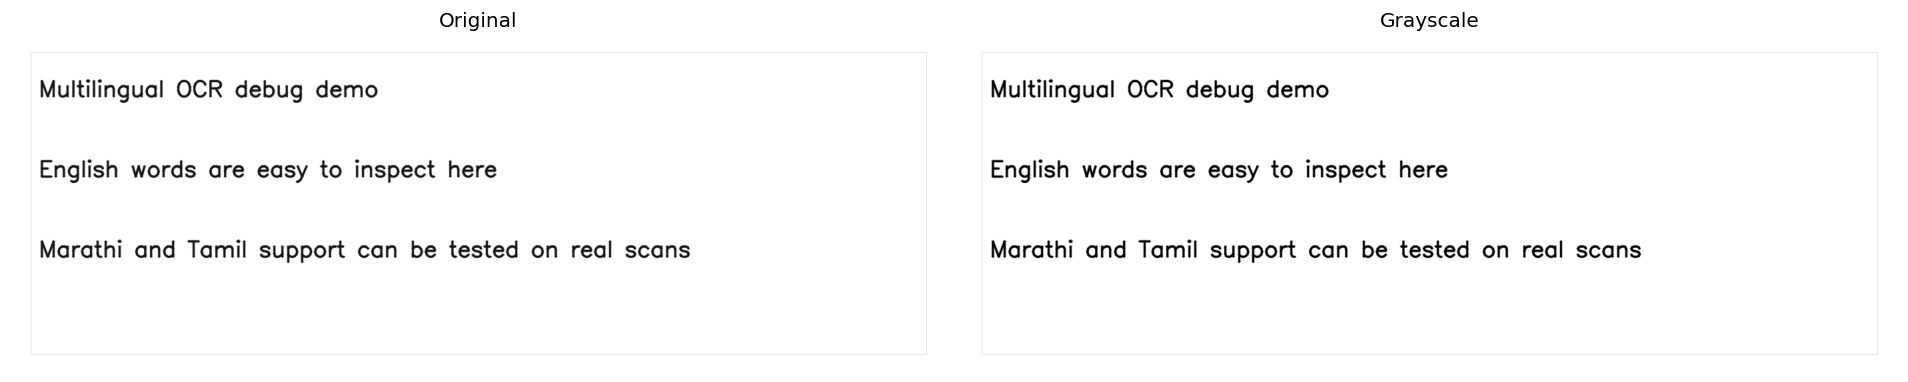

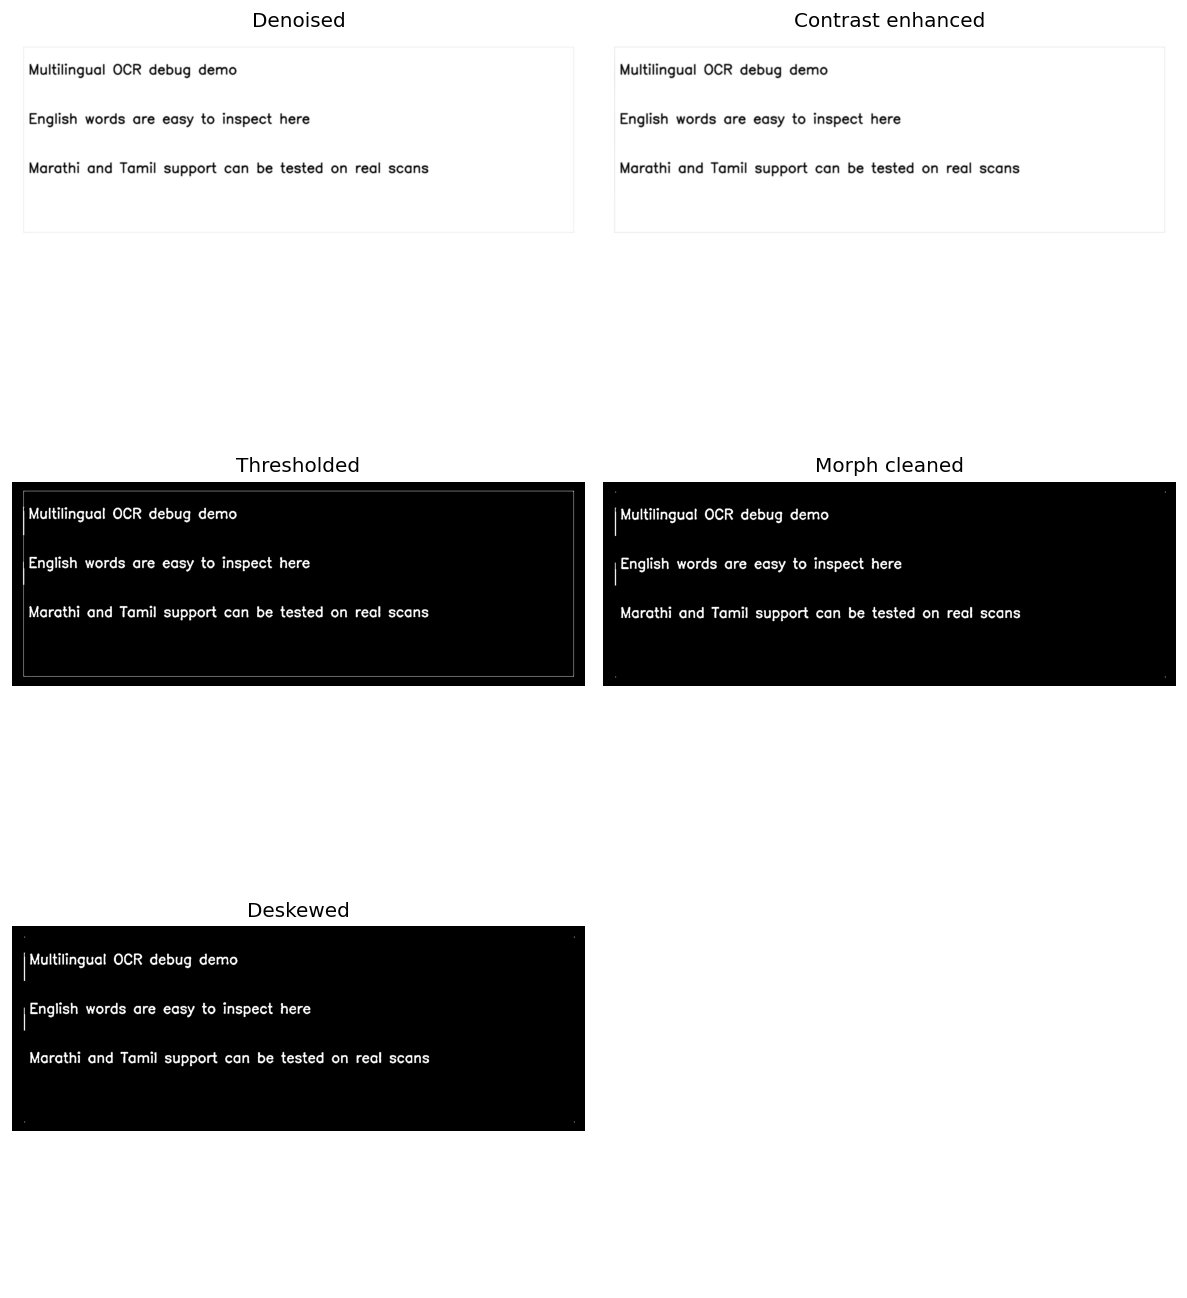

[PIPELINE] Segmenting lines


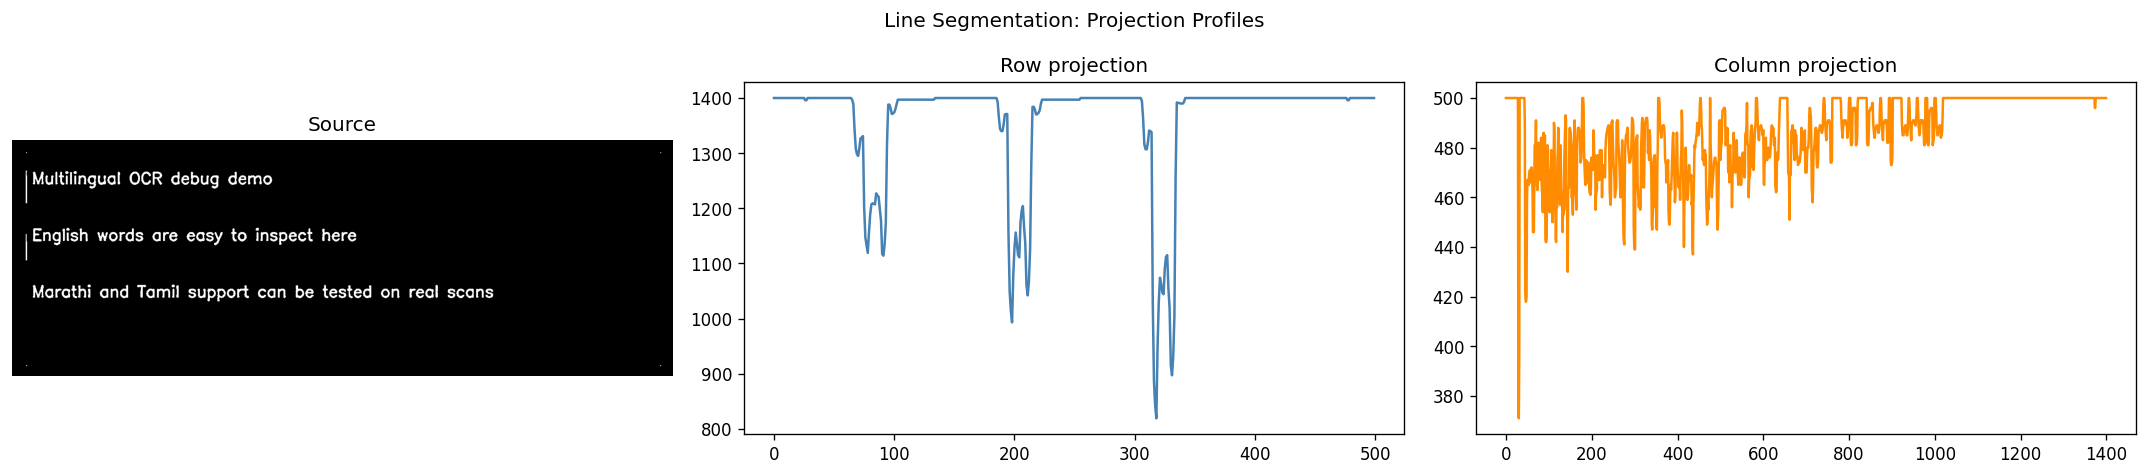

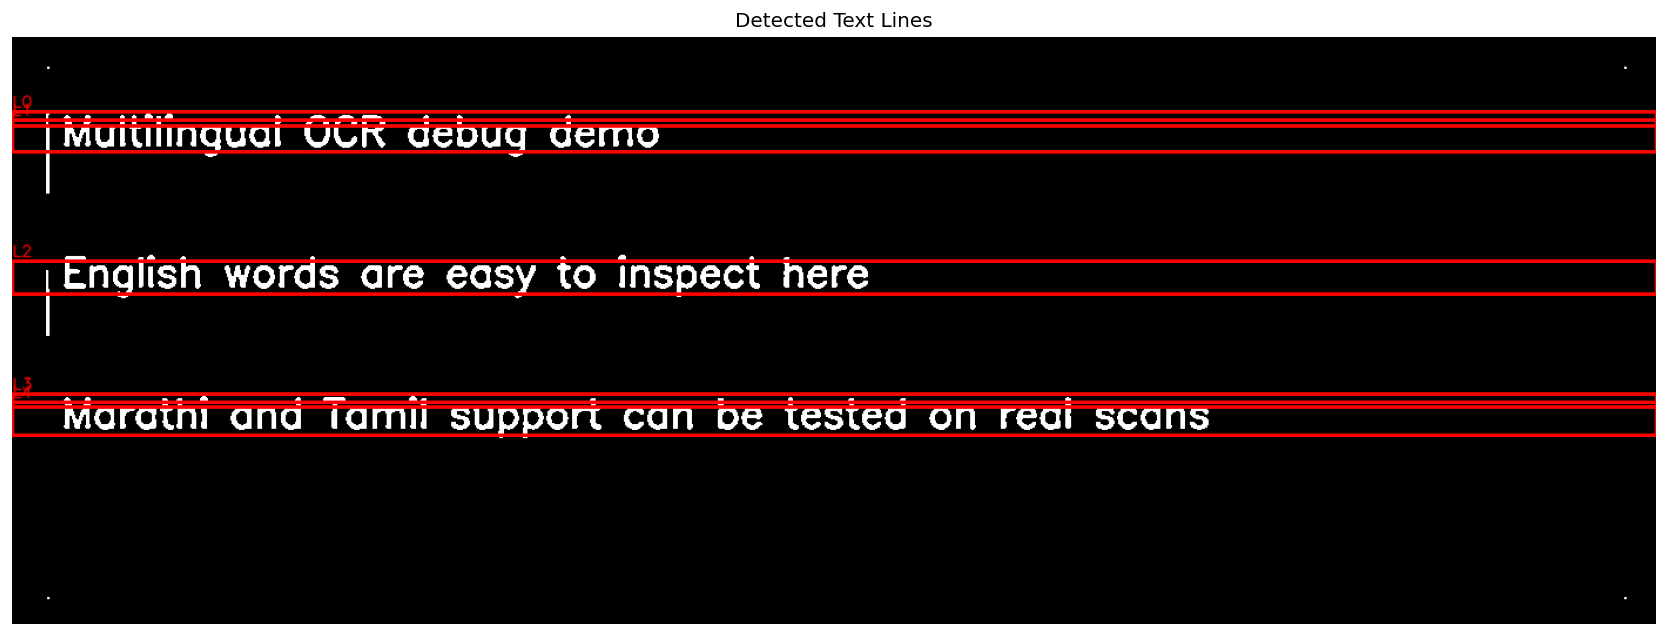

[PIPELINE] Segmenting words in line 0
[PIPELINE] Segmenting words in line 1


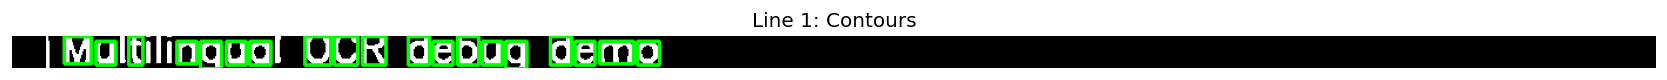

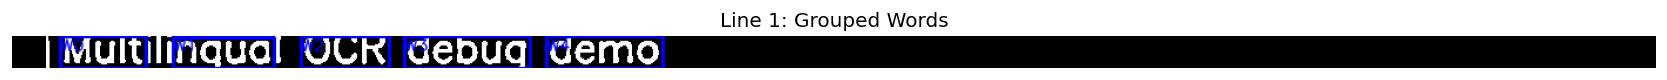

[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=1 word=0 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=1 word=1 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=1 word=2 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=1 word=3 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=1 word=4 lang=English  ocr_lang=eng        conf=0.00 text=''
[PIPELINE] Segmenting words in line 2


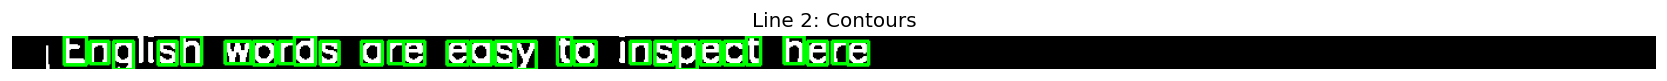

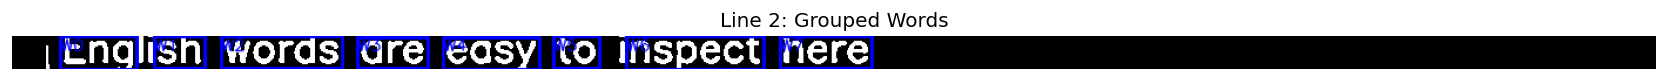

[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=0 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=1 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=2 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=3 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=4 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=5 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=2 word=6 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35

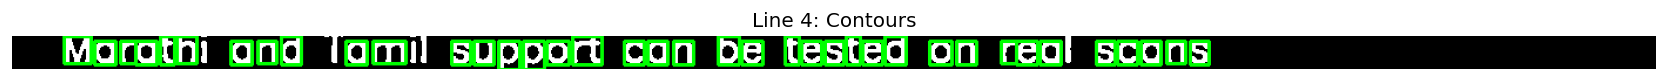

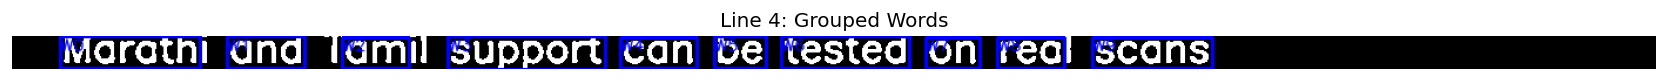

[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=0 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=1 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=2 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=3 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=4 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=5 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35 source=pixel-heuristic
[OCR] line=4 word=6 lang=English  ocr_lang=eng        conf=0.00 text=''
[LANG] predicted=English  confidence=0.35

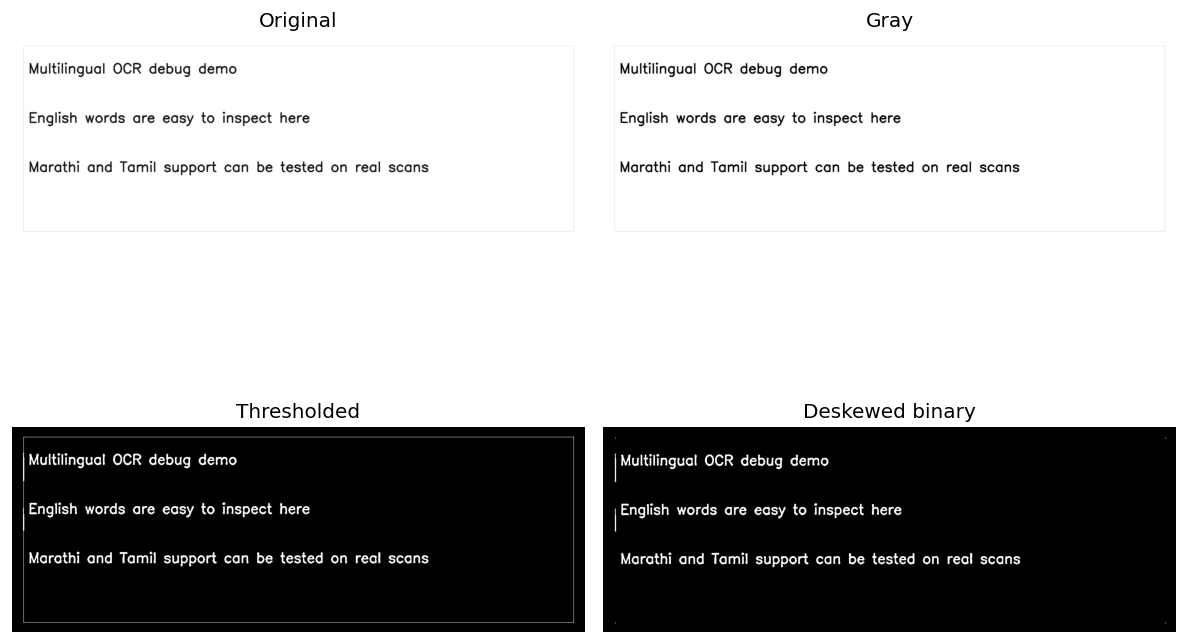

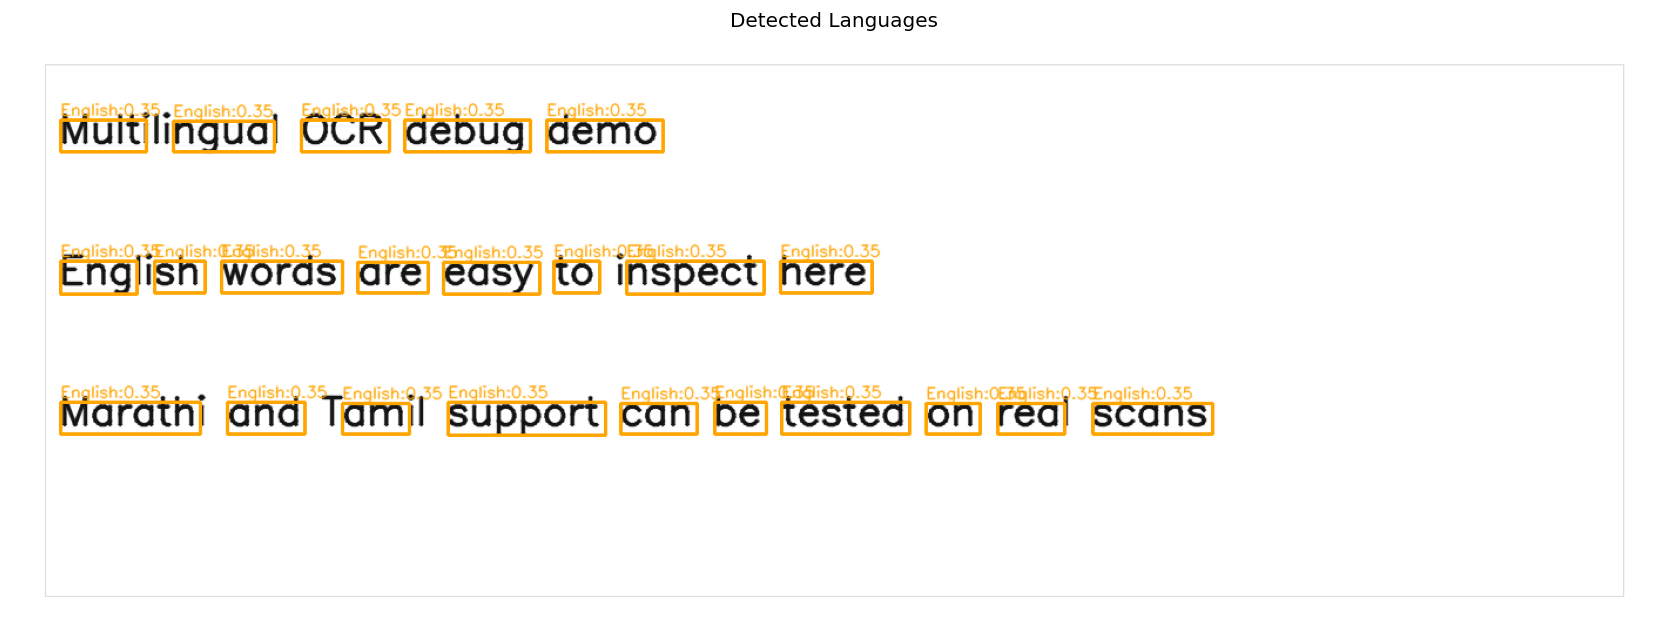

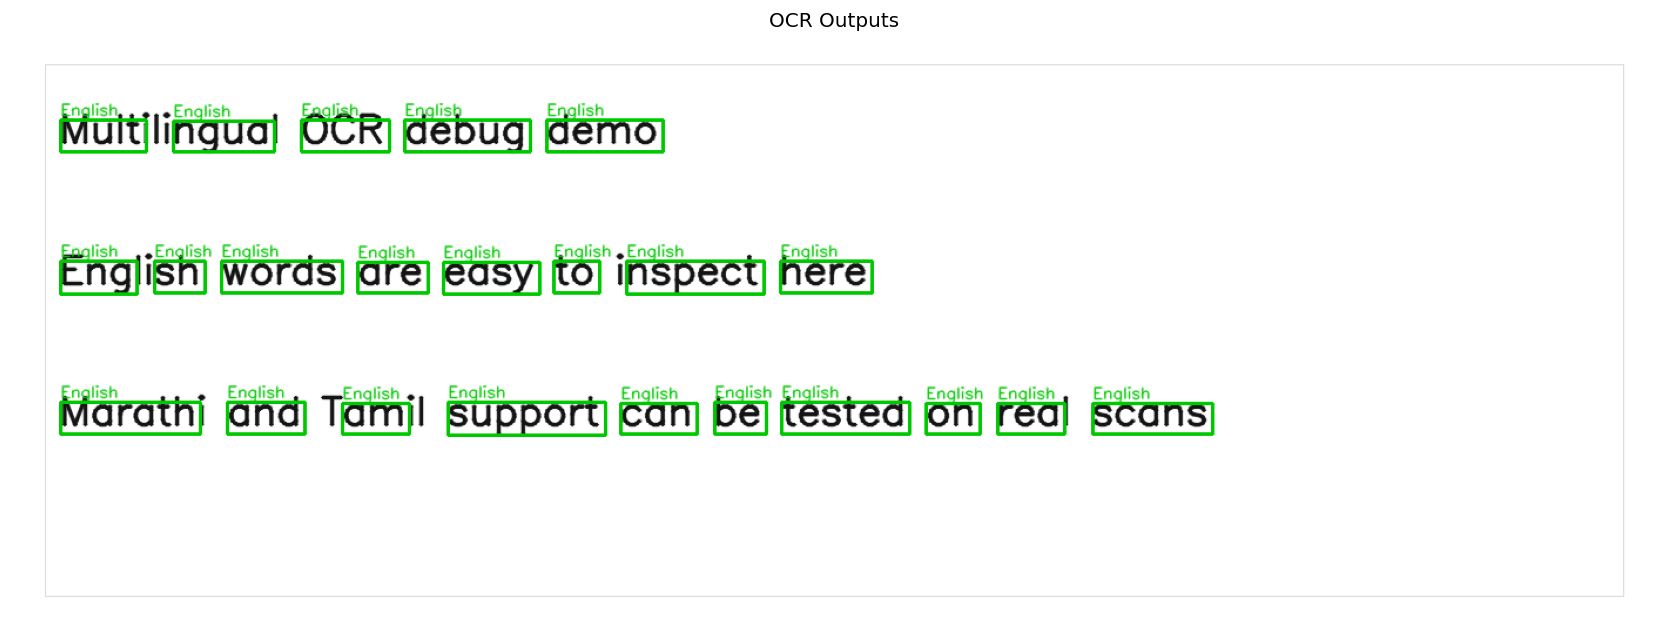


[RESULT] Reconstructed text:




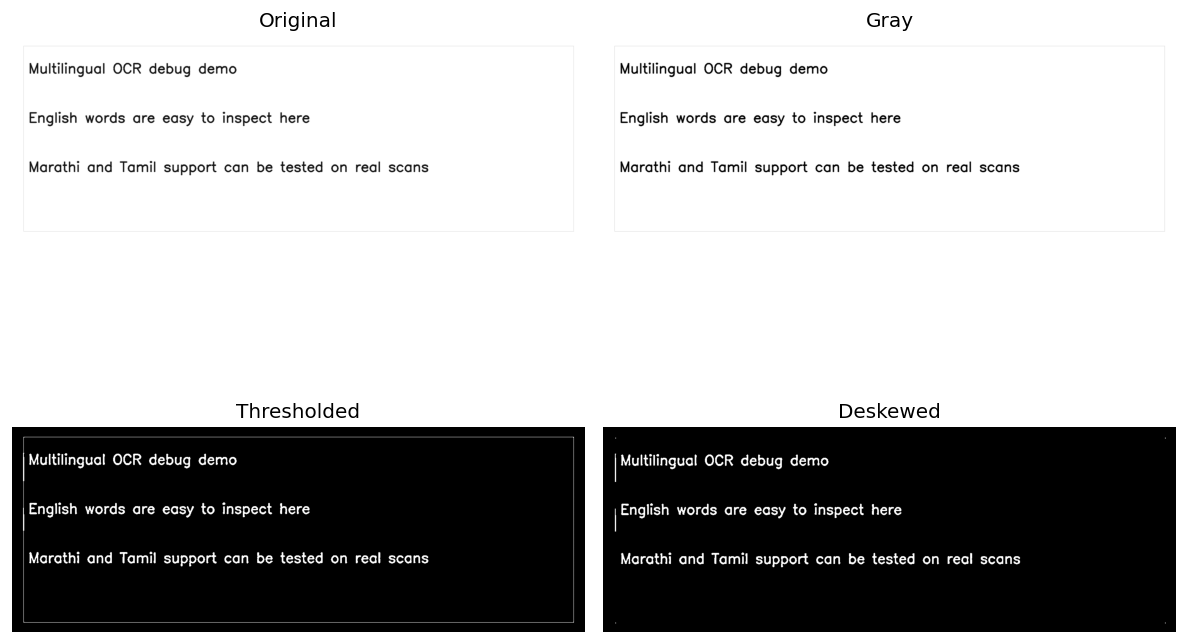

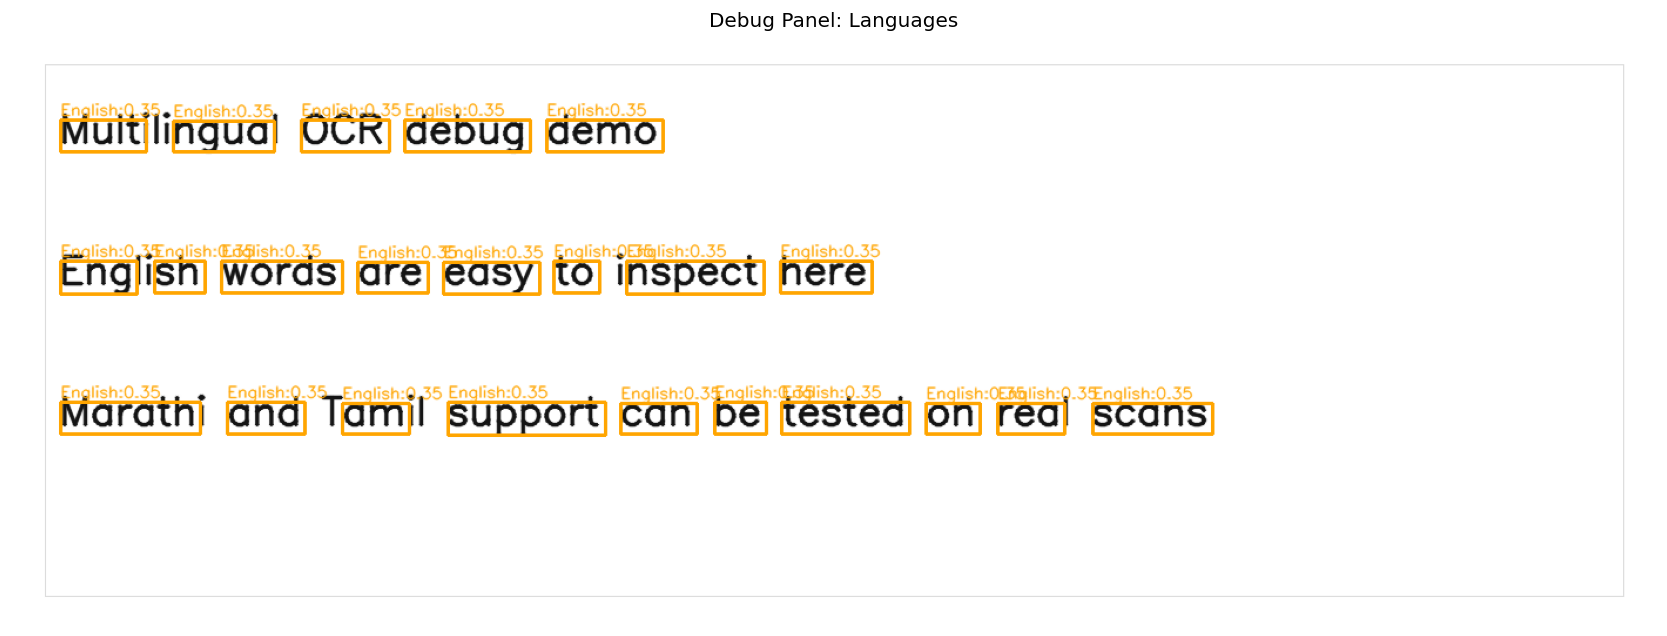

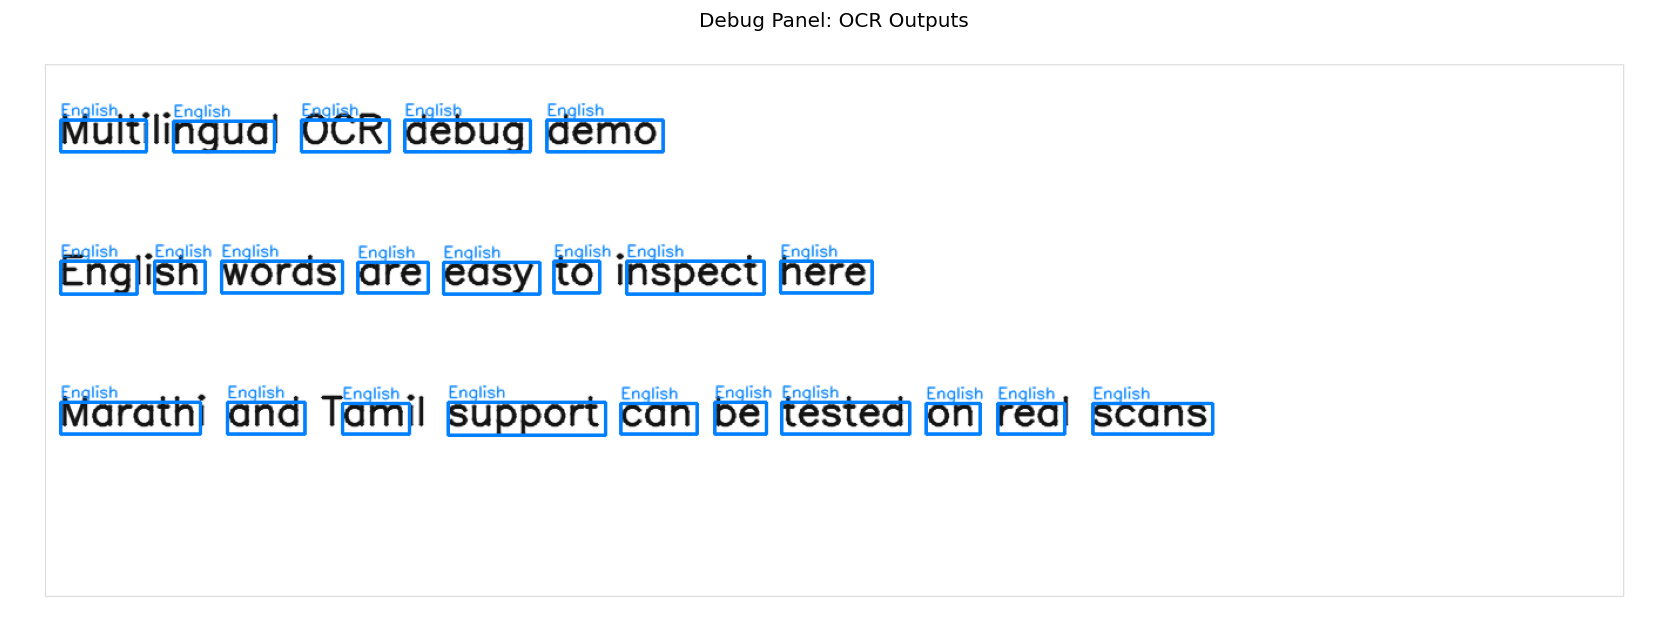


[DEBUG PANEL] Detected words
  line=01 word=00 bbox=(41, 71, 73, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=01 word=01 bbox=(137, 72, 86, 26) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=01 word=02 bbox=(246, 71, 75, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=01 word=03 bbox=(334, 71, 107, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=01 word=04 bbox=(455, 71, 99, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=02 word=00 bbox=(41, 191, 65, 28) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=02 word=01 bbox=(121, 191, 43, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=02 word=02 bbox=(178, 191, 103, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=02 word=03 bbox=(294, 192, 60, 26) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=02 word=04 bbox=(367, 192, 82, 27) lang=English lang_conf=0.35 ocr_conf=0.00 text=''
  line=02 word=05 bbox=(461, 191, 39, 27) lang=English 

In [9]:
# Example execution cell.
# This keeps the notebook runnable even when no real scan is available yet.
example_input = CONFIG["image_path"] if CONFIG["image_path"] is not None else None
pipeline_output = run_full_pipeline(example_input, debug=True)
print("\n[RESULT] Reconstructed text:\n")
print(pipeline_output["reconstructed_text"])

# Show the debug panel explicitly so the notebook ends with a visual summary.
show_debug_panel(pipeline_output, force=True)